In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

from sklearn.model_selection    import train_test_split, cross_val_score
from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.linear_model       import LinearRegression, Ridge
from sklearn.ensemble           import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics            import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline           import Pipeline
from sklearn.inspection         import permutation_importance

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12,
                      "axes.titleweight": "bold", "axes.labelsize": 10})

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [19]:
 !kaggle datasets download -d shree1992/housedata --unzip
 print(" Dataset downloaded!")
 !ls *.csv   # ← this shows you the filename to use in Cell 2

Dataset URL: https://www.kaggle.com/datasets/shree1992/housedata
License(s): unknown
100% 432k/432k [00:00<00:00, 1.12MB/s]

 Dataset downloaded!
data.csv  output.csv


In [18]:
CSV_FILE = "data.csv"
df = pd.read_csv(CSV_FILE)

print("=" * 55)
print("  DATASET LOADED SUCCESSFULLY")
print("=" * 55)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print(f"\n  Column names:\n  {list(df.columns)}\n")
print("FIRST 5 ROWS:")
print(df.head())

  DATASET LOADED SUCCESSFULLY
  Rows    : 4,600
  Columns : 18

  Column names:
  ['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country']

FIRST 5 ROWS:
                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5     

In [5]:
# ── Understand the data ───────────────────────────
print("=" * 55)
print("  DATA TYPES & MISSING VALUES ")
print("=" * 55)
df.info()

print("\n" + "=" * 55)
print("  SUMMARY STATISTICS  ")
print("=" * 55)
print(df.describe().round(2))

print("\n" + "=" * 55)
print("  MISSING VALUES PER COLUMN")
print("=" * 55)
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("No missing values found!")
else:
    print(missing)

  DATA TYPES & MISSING VALUES 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 n

In [6]:
# ── Data Preprocessing ────────────────────────────
print("=" * 55)
print("  PREPROCESSING STEPS")
print("=" * 55)

drop_cols = []

if "id" in df.columns:
    drop_cols.append("id")
    print("  ✓ Dropped 'id' column (just a row number, not a feature)")

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["sale_year"]  = df["date"].dt.year
    df["sale_month"] = df["date"].dt.month
    drop_cols.append("date")
    print("  ✓ Extracted sale_year and sale_month from 'date', then dropped original")

if drop_cols:
    df.drop(columns=drop_cols, inplace=True)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

target_col = "price"   #  our target: what we want to predict

if target_col in num_cols:
    num_cols.remove(target_col)

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  ✓ Filled missing values in '{col}' with median")

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"  ✓ Filled missing values in '{col}' with mode")

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"  ✓ Label-encoded '{col}'")

Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
before = len(df)
df = df[(df[target_col] >= lower) & (df[target_col] <= upper)].reset_index(drop=True)
after = len(df)
print(f"  ✓ Removed {before - after:,} price outliers  |  {after:,} rows remain")

print(f"\n Preprocessing complete. Final dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

  PREPROCESSING STEPS
  ✓ Extracted sale_year and sale_month from 'date', then dropped original
  ✓ Label-encoded 'street'
  ✓ Label-encoded 'city'
  ✓ Label-encoded 'statezip'
  ✓ Label-encoded 'country'
  ✓ Removed 240 price outliers  |  4,360 rows remain

 Preprocessing complete. Final dataset: 4,360 rows × 19 columns


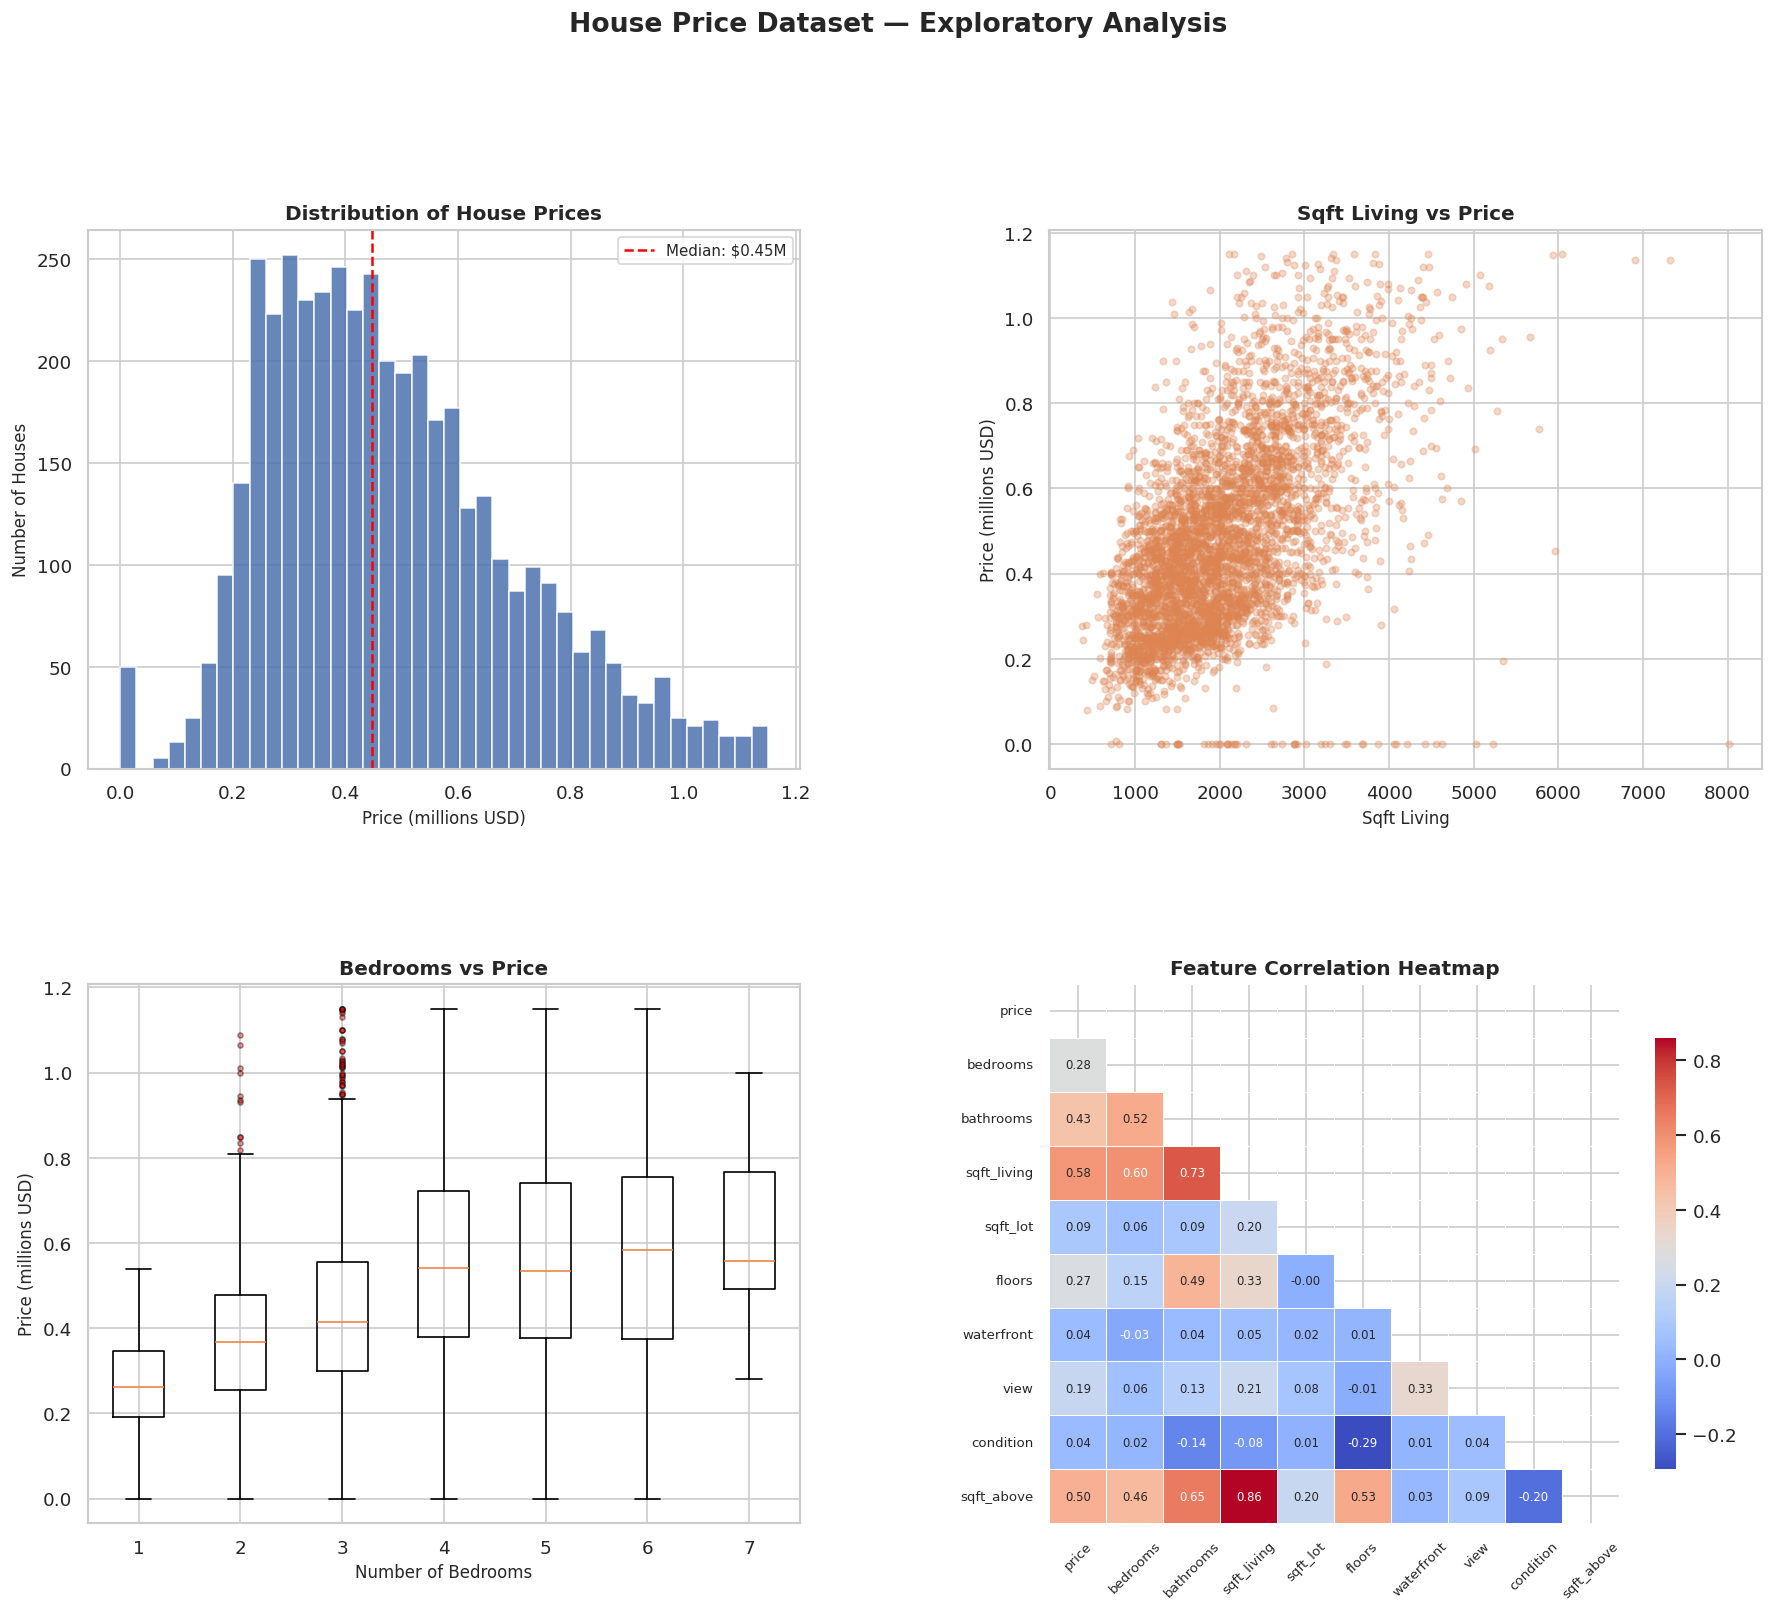

 EDA charts saved as eda_charts.png


In [7]:
#  ── Exploratory Visualizations ────────────────────
# Four charts to understand the data before modeling.

fig = plt.figure(figsize=(18, 14))
fig.suptitle("House Price Dataset — Exploratory Analysis", fontsize=16, fontweight="bold", y=1.01)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Chart 1 — Price Distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df[target_col] / 1e6, bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
ax1.set_title("Distribution of House Prices")
ax1.set_xlabel("Price (millions USD)")
ax1.set_ylabel("Number of Houses")
ax1.axvline(df[target_col].median() / 1e6, color="red", linestyle="--", linewidth=1.5,
            label=f"Median: ${df[target_col].median()/1e6:.2f}M")
ax1.legend(fontsize=9)

# Chart 2 — Sqft Living vs Price (if column exists)
sqft_col = next((c for c in df.columns if "sqft" in c and "living" in c), None)
if sqft_col is None:
    sqft_col = next((c for c in df.columns if "sqft" in c or "area" in c or "size" in c), num_cols[0])

ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(df[sqft_col], df[target_col] / 1e6, alpha=0.3, s=15, color="#DD8452")
ax2.set_title(f"{sqft_col.replace('_',' ').title()} vs Price")
ax2.set_xlabel(sqft_col.replace("_", " ").title())
ax2.set_ylabel("Price (millions USD)")

# Chart 3 — Bedrooms vs Price (if column exists)
bed_col = next((c for c in df.columns if "bed" in c.lower()), None)
if bed_col:
    ax3 = fig.add_subplot(gs[1, 0])
    bedroom_data = [df[df[bed_col] == b][target_col].values / 1e6
                    for b in sorted(df[bed_col].unique()) if df[df[bed_col] == b].shape[0] > 5]
    bedroom_labels = [str(int(b)) for b in sorted(df[bed_col].unique())
                      if df[df[bed_col] == b].shape[0] > 5]
    ax3.boxplot(bedroom_data, labels=bedroom_labels,
                flierprops=dict(marker="o", markerfacecolor="red", markersize=3, alpha=0.4))
    ax3.set_title("Bedrooms vs Price")
    ax3.set_xlabel("Number of Bedrooms")
    ax3.set_ylabel("Price (millions USD)")
else:
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.axis("off")
    ax3.text(0.5, 0.5, "No bedroom column found", ha="center", va="center",
             transform=ax3.transAxes, color="gray")

# Chart 4 — Correlation Heatmap
ax4 = fig.add_subplot(gs[1, 1])
corr_cols = [target_col] + [c for c in num_cols if c != target_col][:9]
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax4, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, annot_kws={"size": 7},
            cbar_kws={"shrink": 0.8})
ax4.set_title("Feature Correlation Heatmap")
ax4.tick_params(axis="x", rotation=45, labelsize=8)
ax4.tick_params(axis="y", rotation=0,  labelsize=8)

plt.savefig("eda_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print(" EDA charts saved as eda_charts.png")

In [8]:
#  ── Feature Selection & Train/Test Split ──────────
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols]
y = df[target_col]

print(f"  Features used : {len(feature_cols)}")
print(f"  Feature names : {feature_cols}\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"  Training rows : {X_train.shape[0]:,}")
print(f"  Test rows     : {X_test.shape[0]:,}")
print("\n Train/test split done — 80% train, 20% test, random_state=42")

  Features used : 18
  Feature names : ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country', 'sale_year', 'sale_month']

  Training rows : 3,488
  Test rows     : 872

✅ Train/test split done — 80% train, 20% test, random_state=42


In [16]:
#  ── Train Models ───────────────────────────────────
print("=" * 55)
print("  TRAINING 3 MODELS — please wait...")
print("=" * 55)

models = {
    "Linear Regression":    Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge Regression":     Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=10.0))]),
    "Gradient Boosting":    Pipeline([("scaler", StandardScaler()),
                                      ("model", GradientBoostingRegressor(
                                           n_estimators=300,
                                           learning_rate=0.08,
                                           max_depth=5,
                                           subsample=0.8,
                                           random_state=42
                                       ))]),
}

results   = {}
y_preds   = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R²": r2}
    y_preds[name] = y_pred

    print(f"\n  ── {name} ──")
    print(f"     MAE  : ${mae:>12,.0f}   (avg prediction error in dollars)")
    print(f"     RMSE : ${rmse:>12,.0f}   (penalises large errors more)")
    print(f"     R²   : {r2:>12.4f}   (1.0 = perfect, 0.0 = no better than mean)")

print("\n All models trained and evaluated!")

  TRAINING 3 MODELS — please wait...

  ── Linear Regression ──
     MAE  : $     124,481   (avg prediction error in dollars)
     RMSE : $     167,952   (penalises large errors more)
     R²   :       0.4307   (1.0 = perfect, 0.0 = no better than mean)

  ── Ridge Regression ──
     MAE  : $     124,527   (avg prediction error in dollars)
     RMSE : $     167,973   (penalises large errors more)
     R²   :       0.4305   (1.0 = perfect, 0.0 = no better than mean)

  ── Gradient Boosting ──
     MAE  : $      77,641   (avg prediction error in dollars)
     RMSE : $     119,772   (penalises large errors more)
     R²   :       0.7105   (1.0 = perfect, 0.0 = no better than mean)

 All models trained and evaluated!


In [10]:
# ── CELL 8 ── Model Comparison Table ────────────────────────

results_df = pd.DataFrame(results).T
results_df["MAE"]  = results_df["MAE"].apply(lambda x: f"${x:,.0f}")
results_df["RMSE"] = results_df["RMSE"].apply(lambda x: f"${x:,.0f}")
results_df["R²"]   = results_df["R²"].apply(lambda x: f"{x:.4f}")

print("=" * 55)
print("  MODEL COMPARISON SUMMARY")
print("=" * 55)
print(results_df.to_string())
print("\n  Lower MAE/RMSE = better    |    Higher R² = better")

best_model_name = min(
    results, key=lambda k: mean_absolute_error(y_test, y_preds[k])
)
print(f"\n   Best model by MAE: {best_model_name}")

  MODEL COMPARISON SUMMARY
                        MAE      RMSE      R²
Linear Regression  $124,481  $167,952  0.4307
Ridge Regression   $124,527  $167,973  0.4305
Gradient Boosting   $77,641  $119,772  0.7105

  Lower MAE/RMSE = better    |    Higher R² = better

  🏆 Best model by MAE: Gradient Boosting


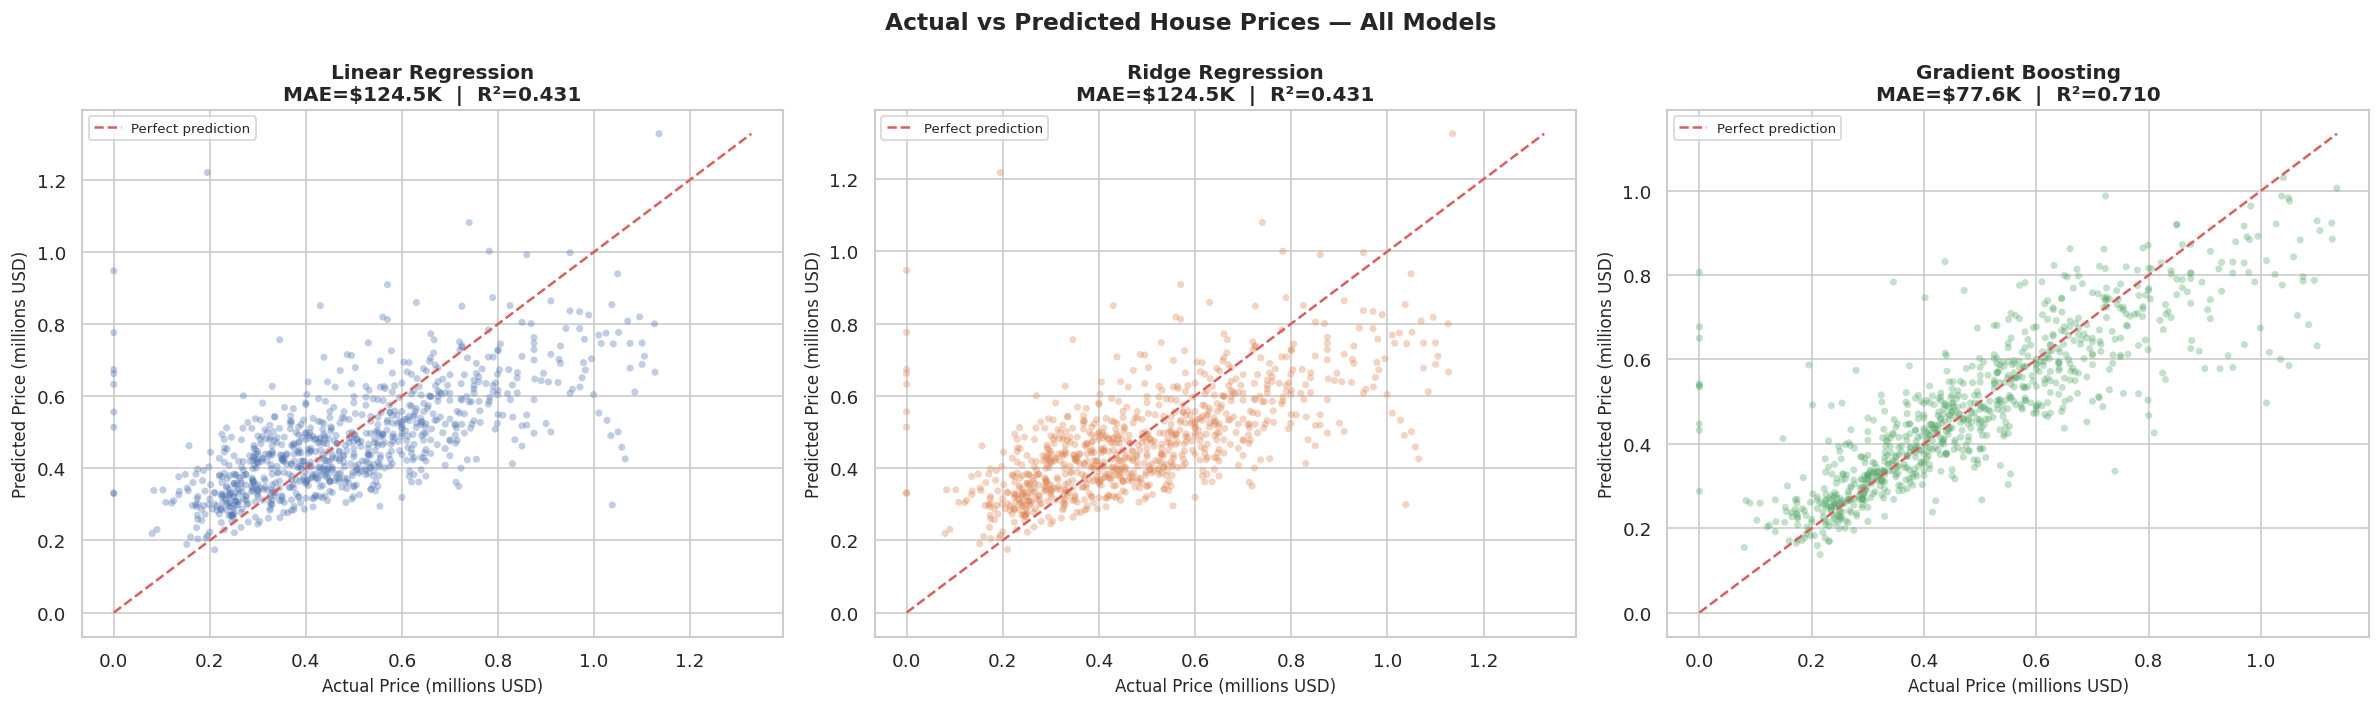

✅ Actual vs Predicted chart saved as actual_vs_predicted.png


In [11]:
# Visualization: Actual vs Predicted ────────────
best_pred = y_preds[best_model_name]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Actual vs Predicted House Prices — All Models", fontsize=14, fontweight="bold")

colors = ["#4C72B0", "#DD8452", "#55A868"]

for idx, (name, y_pred) in enumerate(y_preds.items()):
    ax = axes[idx]
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    # Scatter plot
    ax.scatter(y_test / 1e6, y_pred / 1e6,
               alpha=0.35, s=18, color=colors[idx], edgecolors="none")

    # Perfect prediction line (diagonal)
    mn = min(y_test.min(), y_pred.min()) / 1e6
    mx = max(y_test.max(), y_pred.max()) / 1e6
    ax.plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect prediction")

    ax.set_title(f"{name}\nMAE=${mae/1e3:.1f}K  |  R²={r2:.3f}")
    ax.set_xlabel("Actual Price (millions USD)")
    ax.set_ylabel("Predicted Price (millions USD)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Actual vs Predicted chart saved as actual_vs_predicted.png")

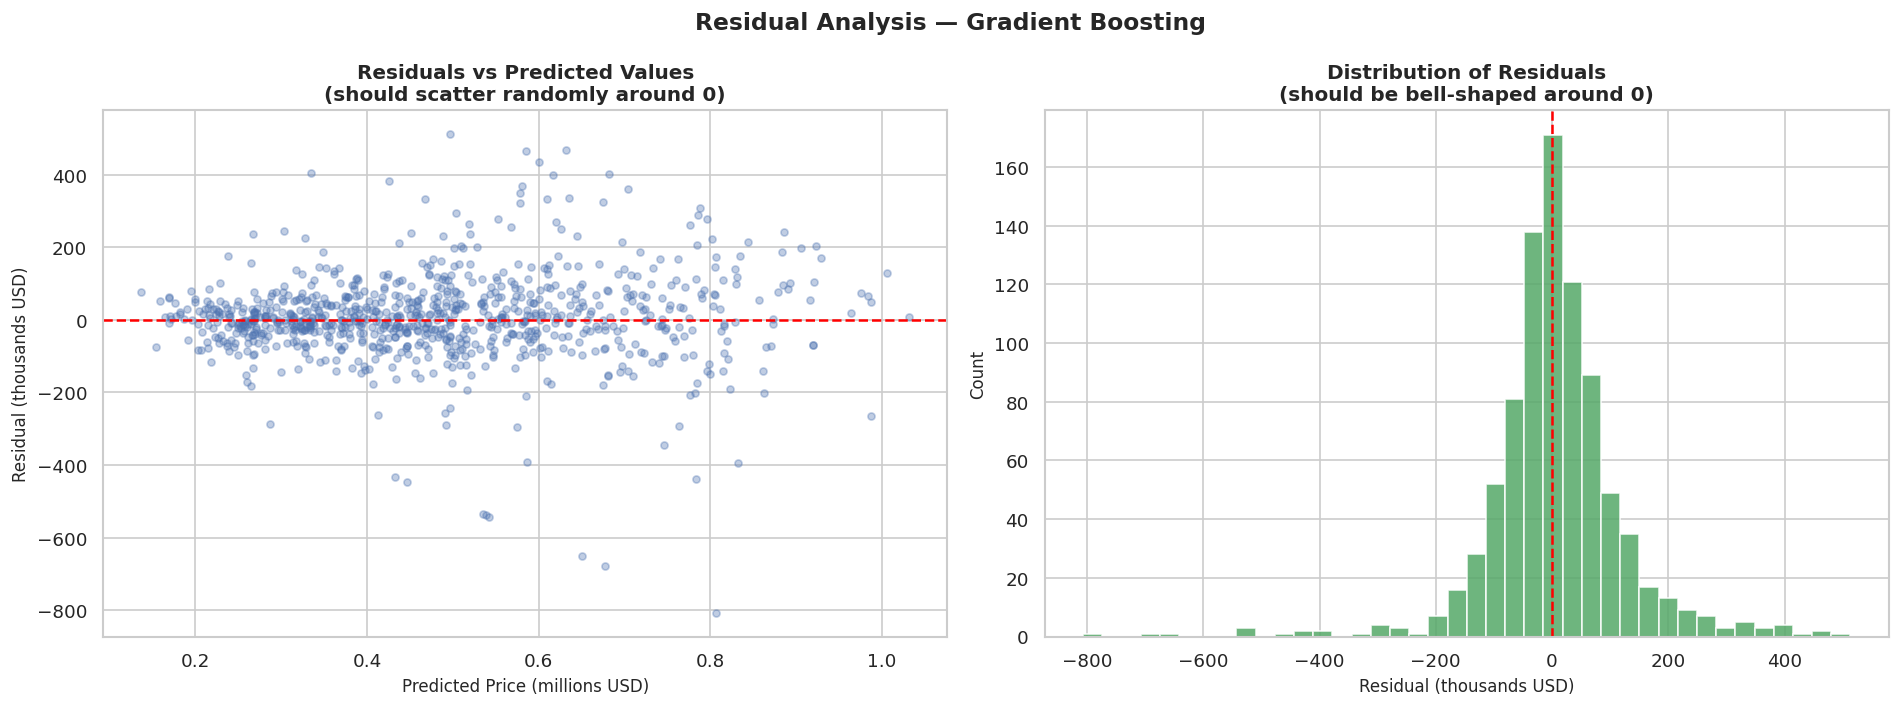

✅ Residual analysis chart saved as residual_analysis.png


In [12]:
#  ── Residual Analysis ───────────────
best_pred  = y_preds[best_model_name]
residuals  = y_test.values - best_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Residual Analysis — {best_model_name}", fontsize=14, fontweight="bold")

# Chart A: Predicted vs Residual
ax = axes[0]
ax.scatter(best_pred / 1e6, residuals / 1e3, alpha=0.35, s=18, color="#4C72B0")
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Predicted Price (millions USD)")
ax.set_ylabel("Residual (thousands USD)")
ax.set_title("Residuals vs Predicted Values\n(should scatter randomly around 0)")

# Chart B: Residual Distribution
ax = axes[1]
ax.hist(residuals / 1e3, bins=40, color="#55A868", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Residual (thousands USD)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Residuals\n(should be bell-shaped around 0)")

plt.tight_layout()
plt.savefig("residual_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Residual analysis chart saved as residual_analysis.png")

Computing permutation importance — takes ~30 seconds...


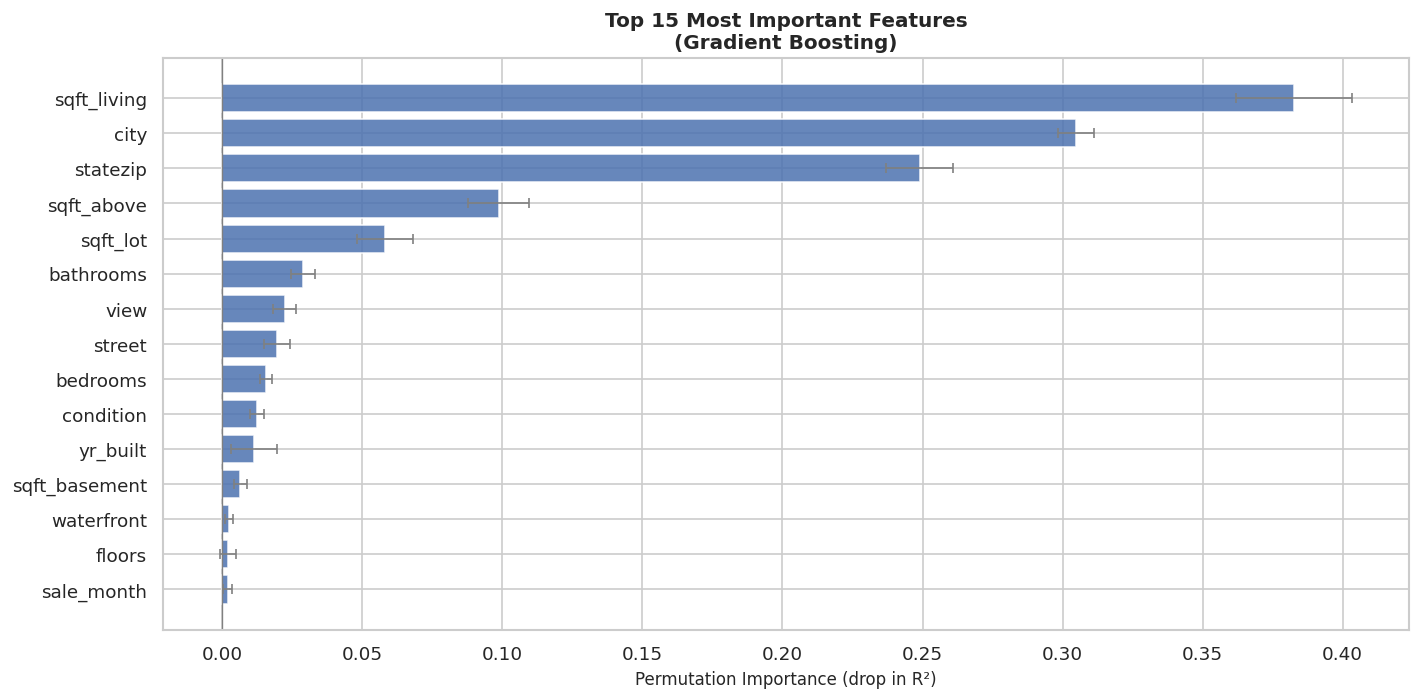

✅ Feature importance chart saved as feature_importance.png


In [13]:
#  ── Feature Importance ───────────────────────────
# Which features matter most for predicting price?
# use permutation importance — measures how much accuracy drops
# randomly shuffle each feature (if accuracy drops a lot → important).

print("Computing permutation importance — takes ~30 seconds...")

best_pipe    = models[best_model_name]
perm_result  = permutation_importance(
    best_pipe, X_test, y_test,
    n_repeats=10, random_state=42, scoring="r2"
)

importance_df = pd.DataFrame({
    "feature":    feature_cols,
    "importance": perm_result.importances_mean,
    "std":        perm_result.importances_std,
}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(importance_df["feature"][::-1],
               importance_df["importance"][::-1],
               xerr=importance_df["std"][::-1],
               color="#4C72B0", edgecolor="white", alpha=0.85,
               error_kw=dict(elinewidth=1, ecolor="gray", capsize=3))
ax.set_xlabel("Permutation Importance (drop in R²)")
ax.set_title(f"Top 15 Most Important Features\n({best_model_name})", fontweight="bold")
ax.axvline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Feature importance chart saved as feature_importance.png")

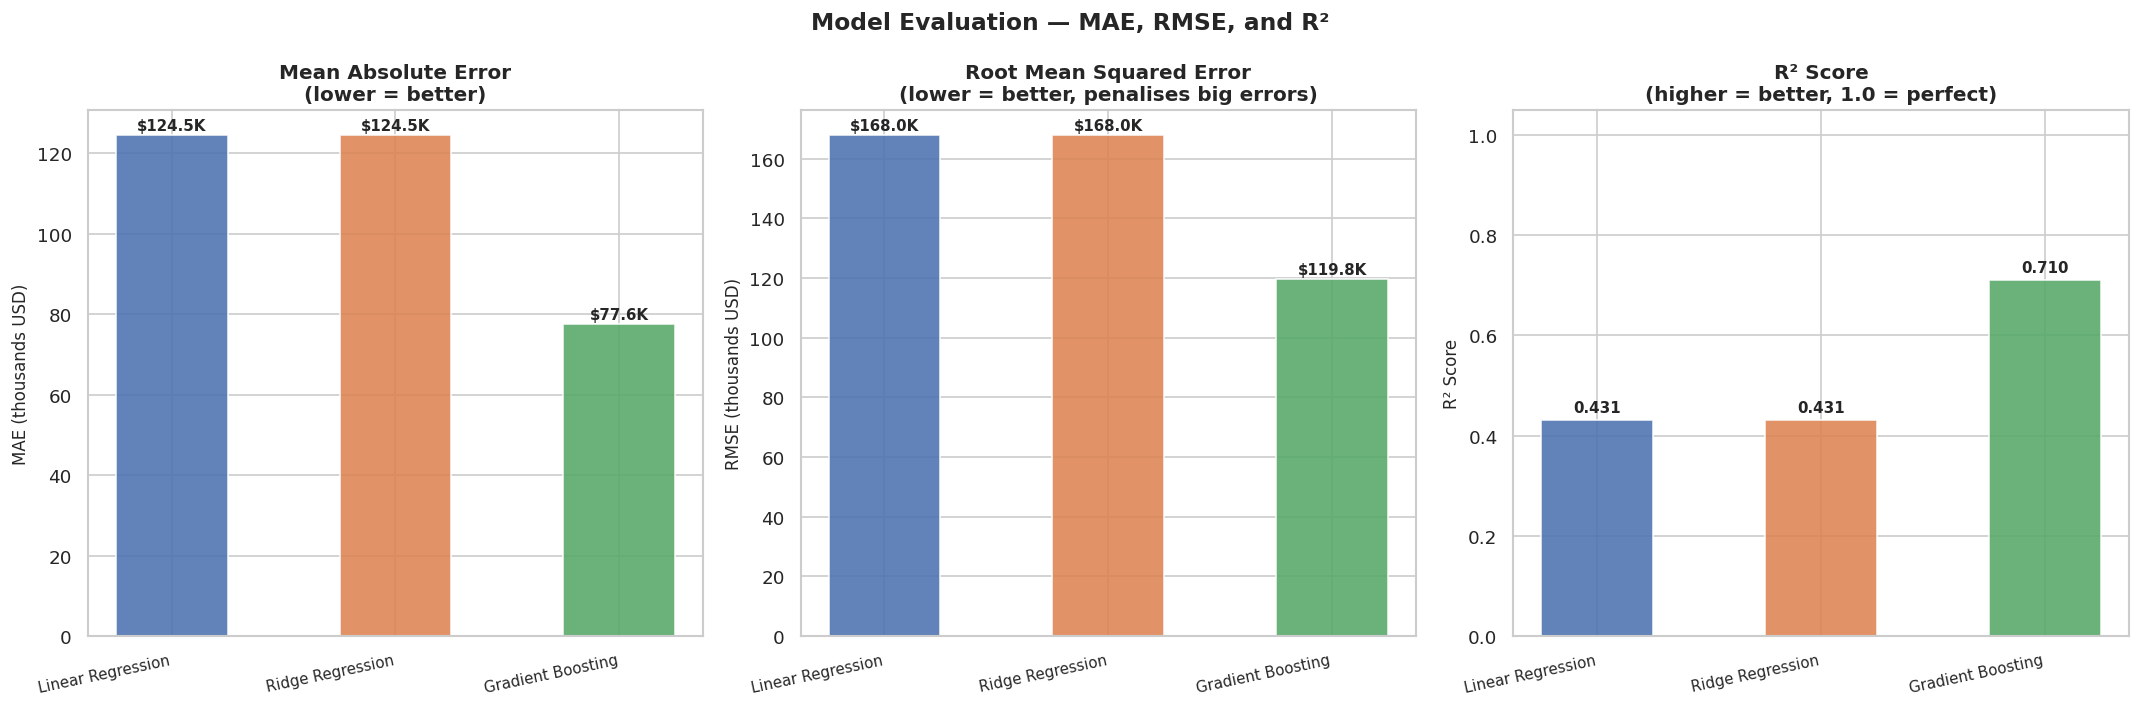

✅ Model metrics chart saved as model_metrics.png


In [14]:
# ── MAE & RMSE Bar Chart Comparison ──────────────
# Visual comparison of error metrics across all three models.

raw_results = {
    name: {
        "MAE":  mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R²":   r2_score(y_test, pred),
    }
    for name, pred in y_preds.items()
}

model_names = list(raw_results.keys())
mae_vals    = [raw_results[m]["MAE"]  / 1e3 for m in model_names]
rmse_vals   = [raw_results[m]["RMSE"] / 1e3 for m in model_names]
r2_vals     = [raw_results[m]["R²"]         for m in model_names]

x = np.arange(len(model_names))
width = 0.3

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Model Evaluation — MAE, RMSE, and R²", fontsize=14, fontweight="bold")

# MAE
ax = axes[0]
bars = ax.bar(x, mae_vals, width=0.5, color=["#4C72B0","#DD8452","#55A868"],
              edgecolor="white", alpha=0.88)
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=12, ha="right", fontsize=9)
ax.set_ylabel("MAE (thousands USD)")
ax.set_title("Mean Absolute Error\n(lower = better)")
for bar, val in zip(bars, mae_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"${val:.1f}K", ha="center", va="bottom", fontsize=9, fontweight="bold")

# RMSE
ax = axes[1]
bars = ax.bar(x, rmse_vals, width=0.5, color=["#4C72B0","#DD8452","#55A868"],
              edgecolor="white", alpha=0.88)
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=12, ha="right", fontsize=9)
ax.set_ylabel("RMSE (thousands USD)")
ax.set_title("Root Mean Squared Error\n(lower = better, penalises big errors)")
for bar, val in zip(bars, rmse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"${val:.1f}K", ha="center", va="bottom", fontsize=9, fontweight="bold")

# R²
ax = axes[2]
bars = ax.bar(x, r2_vals, width=0.5, color=["#4C72B0","#DD8452","#55A868"],
              edgecolor="white", alpha=0.88)
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=12, ha="right", fontsize=9)
ax.set_ylabel("R² Score")
ax.set_title("R² Score\n(higher = better, 1.0 = perfect)")
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("model_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Model metrics chart saved as model_metrics.png")

In [15]:
# ── CELL 13 ── Predict on New/Custom House ──────────────────
# This shows how to use the trained model to predict the price
# of a house you describe yourself.

print("=" * 55)
print("  PREDICT PRICE FOR A CUSTOM HOUSE")
print("=" * 55)

# We create a sample house using the median of each feature.
# In your project, replace these with actual values.
sample_house = pd.DataFrame([X_test.iloc[0]])   # using first test row as example

predicted_price = models[best_model_name].predict(sample_house)[0]
actual_price    = y_test.iloc[0]

print(f"\n  Sample house features (first test row):")
for col, val in zip(feature_cols, sample_house.values[0]):
    print(f"    {col:<22}: {val}")

print(f"\n  Predicted price : ${predicted_price:>12,.0f}")
print(f"  Actual price    : ${actual_price:>12,.0f}")
print(f"  Difference      : ${abs(predicted_price - actual_price):>12,.0f}")

  PREDICT PRICE FOR A CUSTOM HOUSE

  Sample house features (first test row):
    bedrooms              : 4.0
    bathrooms             : 3.0
    sqft_living           : 3100.0
    sqft_lot              : 15480.0
    floors                : 2.0
    waterfront            : 0.0
    view                  : 0.0
    condition             : 3.0
    sqft_above            : 2400.0
    sqft_basement         : 700.0
    yr_built              : 1996.0
    yr_renovated          : 0.0
    street                : 3984.0
    city                  : 17.0
    statezip              : 16.0
    country               : 0.0
    sale_year             : 2014.0
    sale_month            : 5.0

  Predicted price : $     704,170
  Actual price    : $     563,000
  Difference      : $     141,170
